# Final Project: Topic Modeling
## Executive Summary: 
In 180 to 200 words, provide an overview of the notebooks you developed. Describe the use case, data, preprocessing steps, model development, and main points of the analysis. State which model works best or that none of the models were satisfactory and provide reasons. Describe the topics and explain how the model will address the use case, or if none of the models worked well, state what the next steps should be.
## Importing the Dataset: Trip Advisor Reviews


In [44]:
import pandas as pd # data manipulation
import langdetect  # language detection
import matplotlib.pyplot  # plotting
import nltk  # natural language processing
import numpy  # arrays and matrices
import pandas  # dataframes
import pyLDAvis  # plotting
import regex  # regular expressions
import sklearn  # machine learning
import unicodedata  # unicode data manipulation
import random # random number generation

# Text preprocessing and feature extraction
from sklearn.decomposition import NMF  # NMF model
from sklearn.decomposition import LatentDirichletAllocation  # LDA model
from sklearn.feature_extraction.text import TfidfVectorizer # TF-IDF vectorizer
from nltk.stem import WordNetLemmatizer  # lemmatizer
from sklearn.feature_extraction.text import CountVectorizer  # Count vectorizer

# Download necessary NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gly3\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\gly3\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\gly3\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [45]:
url = "https://raw.githubusercontent.com/Hunteracademic/Unsupervised_assignment_1/master/tripadvisor_hotel_reviews.csv"
df = pd.read_csv(url)
df.head()

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


## Preprocessing: 
Clean and prepare text for LDA and NMF topic modeling. Include steps such as case normalization, lemmatization, stop word removal, and tokenization. 

### Language Filter

In [46]:
def do_language_identifying(txt):
    try: the_language = langdetect.detect(txt)
    except: the_language = 'none'
    return the_language

df['Language'] = df['Review'].apply(do_language_identifying)
df['Language'].value_counts()

Language
en    20474
fr        9
af        5
ro        2
nl        1
Name: count, dtype: int64

Removing non-english reviews

In [47]:
reviews_en = df[df['Language'] == 'en']

### Tokenization / Removing Punctuation / Case Normalization

In [48]:
WORD_RE = regex.compile(r"(?V1)\p{L}+(?:[’'-]\p{L}+)*")

def tokenize_for_topics(text):
    text = unicodedata.normalize("NFKC", str(text)).lower()
    text = regex.sub(r"[‘’`´]", "'", text)      # normalize apostrophes
    text = regex.sub(r"[‐‑‒–—−]", "-", text)    # normalize dash variants
    return WORD_RE.findall(text)

reviews_en["Tokens"] = reviews_en["Review"].apply(tokenize_for_topics)

reviews_en['Tokens'][0]

['nice',
 'hotel',
 'expensive',
 'parking',
 'got',
 'good',
 'deal',
 'stay',
 'hotel',
 'anniversary',
 'arrived',
 'late',
 'evening',
 'took',
 'advice',
 'previous',
 'reviews',
 'did',
 'valet',
 'parking',
 'check',
 'quick',
 'easy',
 'little',
 'disappointed',
 'non-existent',
 'view',
 'room',
 'room',
 'clean',
 'nice',
 'size',
 'bed',
 'comfortable',
 'woke',
 'stiff',
 'neck',
 'high',
 'pillows',
 'not',
 'soundproof',
 'like',
 'heard',
 'music',
 'room',
 'night',
 'morning',
 'loud',
 'bangs',
 'doors',
 'opening',
 'closing',
 'hear',
 'people',
 'talking',
 'hallway',
 'maybe',
 'just',
 'noisy',
 'neighbors',
 'aveda',
 'bath',
 'products',
 'nice',
 'did',
 'not',
 'goldfish',
 'stay',
 'nice',
 'touch',
 'taken',
 'advantage',
 'staying',
 'longer',
 'location',
 'great',
 'walking',
 'distance',
 'shopping',
 'overall',
 'nice',
 'experience',
 'having',
 'pay',
 'parking',
 'night']

### Removing Stop Words

In [49]:
list_stop_words = nltk.corpus.stopwords.words("English")
reviews_en['Tokens'] = reviews_en['Tokens'].apply(lambda tokens: [token for token in tokens if token not in list_stop_words])

### Lemmatization

In [50]:
lemmatizer = WordNetLemmatizer()
reviews_en['Tokens'] = reviews_en['Tokens'].apply(lambda tokens: [lemmatizer.lemmatize(token) for token in tokens])

In [51]:
reviews_en['Tokens'].head()

0    [nice, hotel, expensive, parking, got, good, d...
1    [ok, nothing, special, charge, diamond, member...
2    [nice, room, experience, hotel, monaco, seattl...
3    [unique, great, stay, wonderful, time, hotel, ...
4    [great, stay, great, stay, went, seahawk, game...
Name: Tokens, dtype: object

Models: Develop code to first vectorize your text data, and then train at least six LDA and six NMF topic models on these vectors. Use clear section headings for each type of model. Record each set of hyperparameters (for both vectorization and the topic models) that you try, and find the perplexity, word-topic table, and document-topic table for each model. Present this information neatly and use it to select your best LDA and NMF models.

### Vectorizing the text data: LDA

In [52]:
LDA_data = reviews_en.copy()
LDA_data['clean_text'] = LDA_data['Tokens'].apply(lambda tokens: ' '.join(tokens))
LDA_data[['Tokens', 'clean_text']].head()

,Tokens,clean_text
0,"[nice, hotel, expensive, parking, got, good, d...",nice hotel expensive parking got good deal sta...
1,"[ok, nothing, special, charge, diamond, member...",ok nothing special charge diamond member hilto...
2,"[nice, room, experience, hotel, monaco, seattl...",nice room experience hotel monaco seattle good...
3,"[unique, great, stay, wonderful, time, hotel, ...",unique great stay wonderful time hotel monaco ...
4,"[great, stay, great, stay, went, seahawk, game...",great stay great stay went seahawk game awesom...


## Models: 
Develop code to first vectorize your text data, and then train at least six LDA and six NMF topic models on these vectors. Use clear section headings for each type of model. Record each set of hyperparameters (for both vectorization and the topic models) that you try, and find the perplexity, word-topic table, and document-topic table for each model. Present this information neatly and use it to select your best LDA and NMF models.

### Defined Approach:
- Performing grid search on different parameters for the vectorizers in order to select the best combination of parameters + an optimal number of topics.
- Once we select our best combination for the vectorizer, we will explore parameter combinations for the models in order to obtain the best combination and select the best model based on that.

## LDA Exploring

### Selecting our number of topics: Helper Function
Function to explore different number of topics

In [53]:
def perplexity_by_ntopic(data, ntopics, max_df, min_df, max_features):
    """
    Calculate perplexity for different numbers of topics.
    Parameters:
    - data: Document-term matrix (e.g., from CountVectorizer)
    - ntopics: List of numbers of topics to evaluate
    - max_df: Maximum document frequency for term filtering
    - min_df: Minimum document frequency for term filtering
    - max_features: Maximum number of features for term filtering
    Returns:
    - output_df: DataFrame with number of topics and corresponding perplexity scores"""
    
    output_dict = {
        "Number Of Topics": [], 
        "Perplexity Score": []
    }
    
    for t in ntopics:
        lda = sklearn.decomposition.LatentDirichletAllocation(
            n_components=t,
            learning_method="batch",
            random_state=0,
            n_jobs=-1
        )
        lda.fit(data)
        
        output_dict["Number Of Topics"].append(t)
        output_dict["Perplexity Score"].append(lda.perplexity(data))
        print(f"max_df = {max_df}, min_df = {min_df}, max_features = {max_features} : Calculated perplexity for {t} topics: {output_dict['Perplexity Score'][-1]}")
        
    output_df = pandas.DataFrame(output_dict)
    
    index_min_perplexity = output_df["Perplexity Score"].idxmin()
    output_num_topics = output_df.loc[
        index_min_perplexity,  # index
        "Number Of Topics"  # column
    ]
        
    return (output_df, output_num_topics)

### Count Vectorizer Grid Search
According to our research and the examples available in the book, we found that the best word vectorizer for LDA models was `CountVectorizer()`. In this step, we explore different values for a count vectorizer to be used for LDA based on perplexity scores as a starting point for our next exploration.

In [54]:
number_features = 2000 # maximum number of features for CountVectorizer
number_docs = 10 # number of documents to use
number_words = 10

max_dfs = [0.85]
min_dfs = [2, 5, 10]
max_feats = [1000,2000]
# hotel_stop_words = ['hotel', 'room', 'stay', 'really', 'just', 'got', 'went', 'also', 'said', 'told', 'day', 'night', 'time', 'week', 'year',    'place', 'thing', 'way', 'bit', 'lot', 'little', 'came', 'come', 'went', 'going', 'went', 'away', 'check', 'booked', 'booking', 'trip', 'visit', 'stayed', 'rooms', 'hotels', 'stays']

# Create a list of CountVectorizer instances with different parameter combinations
count_vectorizers = []
for max_df in max_dfs:
    for min_df in min_dfs:
        for max_features in max_feats:
            vectorizer = CountVectorizer(
                max_df=max_df,
                min_df=min_df,
                max_features=max_features
                # stop_words=hotel_stop_words
            )
            count_vectorizers.append(vectorizer)

In [55]:
# Calculate perplexity for each CountVectorizer and store results in a list of DataFrames
perplexity_dfs = []
for cv in count_vectorizers:
    dtm_cv = cv.fit_transform(LDA_data['clean_text'])
    # Exploring Perplexity for LDA
    lda_perplexity, optimal_num_topics = perplexity_by_ntopic(
    dtm_cv,
    [3, 4, 5, 6],
    cv.max_df,
    cv.min_df,
    cv.max_features
    )

    lda_perplexity['Max_Features'] = cv.max_features
    lda_perplexity['Max_DF'] = cv.max_df
    lda_perplexity['Min_DF'] = cv.min_df
    perplexity_dfs.append(lda_perplexity)

max_df = 0.85, min_df = 2, max_features = 1000 : Calculated perplexity for 3 topics: 472.4252817655819
max_df = 0.85, min_df = 2, max_features = 1000 : Calculated perplexity for 4 topics: 472.2734876117587
max_df = 0.85, min_df = 2, max_features = 1000 : Calculated perplexity for 5 topics: 471.52625942986106
max_df = 0.85, min_df = 2, max_features = 1000 : Calculated perplexity for 6 topics: 472.5950749279347
max_df = 0.85, min_df = 2, max_features = 2000 : Calculated perplexity for 3 topics: 741.535383934534
max_df = 0.85, min_df = 2, max_features = 2000 : Calculated perplexity for 4 topics: 731.5202420407669
max_df = 0.85, min_df = 2, max_features = 2000 : Calculated perplexity for 5 topics: 730.054161078227
max_df = 0.85, min_df = 2, max_features = 2000 : Calculated perplexity for 6 topics: 724.6474707074731
max_df = 0.85, min_df = 5, max_features = 1000 : Calculated perplexity for 3 topics: 477.8407371111351
max_df = 0.85, min_df = 5, max_features = 1000 : Calculated perplexity for

In [56]:
perp_concat = pd.concat(perplexity_dfs, ignore_index=True)
perp_concat.sort_values(by='Perplexity Score', inplace=True)
perp_concat.head(10)

,Number Of Topics,Perplexity Score,Max_Features,Max_DF,Min_DF
10,5,470.008065,1000,0.85,5
17,4,470.536302,1000,0.85,10
9,4,470.638495,1000,0.85,5
19,6,471.129703,1000,0.85,10
2,5,471.526259,1000,0.85,2
16,3,472.022583,1000,0.85,10
11,6,472.130526,1000,0.85,5
1,4,472.273488,1000,0.85,2
18,5,472.347470,1000,0.85,10
0,3,472.425282,1000,0.85,2


### LDA Parameters Grid Search
We defined the best parameters combination for the count vectorizer definition based on the results above as `cv_final`. This vectorizer is then used to explore different LDA model options.
We are going to store each model using the `max_iter` parameter as the key and the values as the models themselves.

In [58]:
cv_final = CountVectorizer(
    max_df=0.85,        
    min_df=10,          
    max_features=1000,
    ngram_range=(1, 2)
)
 
dtm_cv_final = cv_final.fit_transform(LDA_data['clean_text'])
 
max_iter = [10, 20, 30, 40, 50]
selected_num_topics = [4, 5, 6]
lda_models_arr = {} # Initialize an empty dictionary to store LDA models with max_iter and num_topics as keys

for iter in max_iter:
    for num_topics in selected_num_topics:
        lda_model = LatentDirichletAllocation(n_components=num_topics, random_state=0, max_iter=iter, n_jobs=-1)
        lda_model.fit(dtm_cv_final)
        lda_models_arr[(iter, num_topics)] = lda_model
        print(f"Max Iterations: {iter} - Number of Topics: {num_topics} - Perplexity: {lda_model.perplexity(dtm_cv_final)}")

Max Iterations: 10 - Number of Topics: 4 - Perplexity: 484.74331406433436
Max Iterations: 10 - Number of Topics: 5 - Perplexity: 483.3566141132015
Max Iterations: 10 - Number of Topics: 6 - Perplexity: 483.4051730041018
Max Iterations: 20 - Number of Topics: 4 - Perplexity: 483.76953989007706
Max Iterations: 20 - Number of Topics: 5 - Perplexity: 482.2261511917175
Max Iterations: 20 - Number of Topics: 6 - Perplexity: 481.73273776377516
Max Iterations: 30 - Number of Topics: 4 - Perplexity: 483.52707652616834
Max Iterations: 30 - Number of Topics: 5 - Perplexity: 481.95476781779263
Max Iterations: 30 - Number of Topics: 6 - Perplexity: 481.4327171640359
Max Iterations: 40 - Number of Topics: 4 - Perplexity: 483.45507980496666
Max Iterations: 40 - Number of Topics: 5 - Perplexity: 481.86031823666366
Max Iterations: 40 - Number of Topics: 6 - Perplexity: 481.3680055915092
Max Iterations: 50 - Number of Topics: 4 - Perplexity: 483.423273869762
Max Iterations: 50 - Number of Topics: 5 - Pe

### Interpretability Check: Words and Document Matrices of models

In [59]:
def get_topics(mod, vec, names, docs, ndocs, nwords):
    # word to topic matrix
    W = mod.components_
    W_norm = W / W.sum(axis=1)[:, numpy.newaxis]
    # topic to document matrix
    H = mod.transform(vec)
    
    W_dict = {}
    H_dict = {}
    
    for tpc_idx, tpc_val in enumerate(W_norm):
        topic = "Topic{}".format(tpc_idx)
        
        # formatting w
        W_indices = tpc_val.argsort()[::-1][:nwords]
        W_names_values = [
            (round(tpc_val[j], 4), names[j]) 
            for j in W_indices
        ]
        W_dict[topic] = W_names_values
        
        # formatting h
        H_indices = H[:, tpc_idx].argsort()[::-1][:ndocs]
        H_names_values = [
            (round(H[:, tpc_idx][j], 4), docs[j]) 
            for j in H_indices
        ]
        H_dict[topic] = H_names_values
        
    W_df = pd.DataFrame(
        W_dict, 
        index=["Word" + str(i) for i in range(nwords)]
    )
    H_df = pd.DataFrame(
        H_dict,
        index=["Doc" + str(i) for i in range(ndocs)]
    )
        
    return (W_df, H_df)

In [60]:
W_df, H_df = get_topics(
    mod=lda_models_arr[(50, 6)],
    vec=dtm_cv_final,
    names=cv_final.get_feature_names_out(),
    docs=df['Review'].tolist(),
    ndocs=number_docs, 
    nwords=number_words
)
print('*' * 50)
print("Word - Topic Table:")
print('*' * 50)
print(W_df)

print('*' * 50)
print("Document - Topic Table:")
print('*' * 50)
print(H_df)

**************************************************
Word - Topic Table:
**************************************************
                 Topic0               Topic1               Topic2  \
Word0  (0.0229, resort)      (0.0575, hotel)       (0.078, hotel)   
Word1    (0.022, beach)       (0.0312, room)      (0.0383, great)   
Word2    (0.0165, food)       (0.0279, good)      (0.0345, staff)   
Word3    (0.0142, good)   (0.0177, location)       (0.0274, stay)   
Word4     (0.0138, day)  (0.0173, breakfast)        (0.025, room)   
Word5    (0.0137, time)       (0.0136, walk)   (0.0187, location)   
Word6   (0.0134, great)      (0.0116, clean)     (0.0168, stayed)   
Word7    (0.0125, pool)      (0.0104, night)   (0.0161, friendly)   
Word8    (0.0115, room)      (0.0101, great)     (0.015, helpful)   
Word9  (0.0107, people)      (0.01, station)  (0.0119, excellent)   

                Topic3             Topic4               Topic5  
Word0   (0.0591, room)      (0.044, room)      (0.029

## Discussion: 
For the best LDA and NMF models, present again the perplexity for each, and display the word-topic and document-topic tables. For your best LDA model, create a biplot visualization using the pyLDAvis package and a t-SNE visualization to explore document-topic relationships in lower-dimensional space. Experiment with values of the relevance metric and be prepared to demonstrate this to your instructor. Write a clear description, in your own words, of the abstract topics found by each model and present this information neatly. Discuss which model has done the best job of identifying topics for your use case and justify this by referring to the analysis and visualizations.
### LDA Visualizations: Biplot

In [63]:
import gc
import pyLDAvis
import pyLDAvis.lda_model as sklearn_lda

best_lda = lda_models_arr[(50, 6)]
#del lda_models_arr
gc.collect()

lda_plot = sklearn_lda.prepare(
    best_lda,
    dtm_cv_final,
    cv_final,
    R=10,
    n_jobs=1,
    lambda_step=0.1
)
pyLDAvis.display(lda_plot)

### LDA Visualizations: T-SNE

In [64]:
# define functiont to fit and plot t-SNE model

def plot_tsne(data, threshold):
    # filter data according to threshold
    index_meet_threshold = numpy.amax(data, axis=1) >= threshold
    lda_transform_filt = data[index_meet_threshold]
    
    # fit tsne model
    # x-d -> 2-d, x = number of topics
    tsne = sklearn.manifold.TSNE(
        n_components=2, 
        verbose=0, 
        random_state=0, 
        angle=0.5, 
        init='pca'
    )
    tsne_fit = tsne.fit_transform(lda_transform_filt)
    
    # most probable topic for each headline
    most_prob_topic = []
    for i in range(tsne_fit.shape[0]):
        most_prob_topic.append(lda_transform_filt[i].argmax())
    
    print("LENGTH:\n{}\n".format(len(most_prob_topic)))

    unique, counts = numpy.unique(
        numpy.array(most_prob_topic), 
        return_counts=True
    )

    print("COUNTS:\n{}\n".format(numpy.asarray((unique, counts)).T))
    
    # make plot
    color_list = ['b', 'g', 'r', 'c', 'm', 'y', 'k']

    for i in list(set(most_prob_topic)):
        indices = [idx for idx, val in enumerate(most_prob_topic) if val == i]
        matplotlib.pyplot.scatter(
            x=tsne_fit[indices, 0], 
            y=tsne_fit[indices, 1], 
            s=0.5, 
            c=color_list[i], 
            label='Topic' + str(i),
            alpha=0.25
        )

    matplotlib.pyplot.xlabel('x-tsne')
    matplotlib.pyplot.ylabel('y-tsne')
    matplotlib.pyplot.legend(markerscale=10)

LENGTH:
4795

COUNTS:
[[   0 1771]
 [   1 1112]
 [   2  807]
 [   3  676]
 [   4  362]
 [   5   67]]



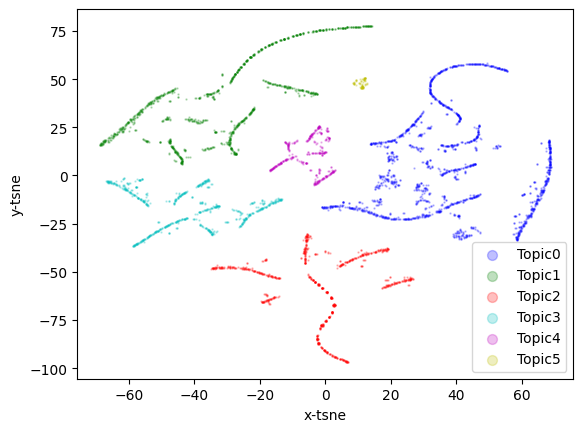

In [65]:
lda_transform = best_lda.transform(dtm_cv_final)
plot_tsne(data=lda_transform, threshold=0.75)

### Vectorization for NMF
### Hyperparameter Stack:
.....

In [66]:
# Create a dedicated NMF dataframe from your english reviews
nmf_data = reviews_en.copy()

# Ensure the clean_text column exists (joining the lemmatized tokens)
nmf_data['clean_text'] = nmf_data['Tokens'].apply(lambda tokens: ' '.join(tokens))

# Preview the clean data
nmf_data[['Review', 'clean_text']].head()

,Review,clean_text
0,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...
1,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...
2,nice rooms not 4* experience hotel monaco seat...,nice room experience hotel monaco seattle good...
3,"unique, great stay, wonderful time hotel monac...",unique great stay wonderful time hotel monaco ...
4,"great stay great stay, went seahawk game aweso...",great stay great stay went seahawk game awesom...


In [67]:
tfidf_vectorizer = TfidfVectorizer(
    max_df=0.95,        
    min_df=2,           
    max_features=2000   
    )

dtm_tfidf = tfidf_vectorizer.fit_transform(nmf_data['clean_text'])

In [68]:
print(dtm_tfidf[0])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 61 stored elements and shape (1, 2000)>
  Coords	Values
  (0, 1135)	0.30539628208143416
  (0, 844)	0.07321724560666153
  (0, 618)	0.10583454209732084
  (0, 1231)	0.3550983749121127
  (0, 752)	0.0789128307169921
  (0, 750)	0.05412603305939885
  (0, 455)	0.11216946863627215
  (0, 1672)	0.10301701260193437
  (0, 66)	0.15410714277678453
  (0, 89)	0.09567567778272272
  (0, 945)	0.11210433851546711
  (0, 593)	0.10537897249652624
  (0, 1795)	0.09707327445117016
  (0, 29)	0.14346386362347224
  (0, 1327)	0.13453172030669325
  (0, 1460)	0.08259211111924436
  (0, 1883)	0.14918963501183785
  (0, 302)	0.08800125974791928
  (0, 1373)	0.12873586245854107
  (0, 552)	0.10252550417406027
  (0, 979)	0.07721015147803532
  (0, 501)	0.11739624428795302
  (0, 1146)	0.1310285072419221
  (0, 1892)	0.07825598360113478
  (0, 1479)	0.10633295131728616
  :	:
  (0, 1100)	0.0913879948028702
  (0, 1000)	0.14158094620872794
  (0, 517)	0.09324553193838282
  

In [69]:
# Initialize the NMF model
nmf_model = NMF(n_components=5, random_state=42, init='nndsvd')

# Fit the model to your Count Vectorized data
nmf_model.fit(dtm_tfidf)

# Get the vocabulary names
nmf_feature_names = tfidf_vectorizer.get_feature_names_out()

# Display the Top 10 words for each NMF topic
for index, topic in enumerate(nmf_model.components_):
    print(f'THE TOP 10 WORDS FOR NMF TOPIC #{index}')
    top_word_indices = topic.argsort()[-10:]
    print([nmf_feature_names[i] for i in top_word_indices])
    print('\n')

THE TOP 10 WORDS FOR NMF TOPIC #0
['wonderful', 'paris', 'recommend', 'excellent', 'best', 'service', 'stayed', 'stay', 'staff', 'hotel']


THE TOP 10 WORDS FOR NMF TOPIC #1
['drink', 'restaurant', 'good', 'people', 'time', 'day', 'pool', 'food', 'beach', 'resort']


THE TOP 10 WORDS FOR NMF TOPIC #2
['bathroom', 'stay', 'day', 'view', 'check', 'desk', 'floor', 'night', 'bed', 'room']


THE TOP 10 WORDS FOR NMF TOPIC #3
['room', 'nice', 'minute', 'clean', 'hotel', 'location', 'station', 'breakfast', 'walk', 'good']


THE TOP 10 WORDS FOR NMF TOPIC #4
['stayed', 'clean', 'room', 'helpful', 'friendly', 'place', 'staff', 'stay', 'location', 'great']




In [70]:
# Transform the numerical matrix to get topic weights
# This shows how much each document belongs to each of the 5 topics
nmf_topic_results = nmf_model.transform(dtm_tfidf)

# Assign the winning topic index to the dataframe
nmf_data['Topic'] = nmf_topic_results.argmax(axis=1)

# Reorder columns and fix the naming to match your notebook's case-sensitivity
nmf_data = nmf_data[['Review', 'Rating', 'Topic', 'Tokens']]

# Preview results
nmf_data.head()

,Review,Rating,Topic,Tokens
0,nice hotel expensive parking got good deal sta...,4,2,"[nice, hotel, expensive, parking, got, good, d..."
1,ok nothing special charge diamond member hilto...,2,2,"[ok, nothing, special, charge, diamond, member..."
2,nice rooms not 4* experience hotel monaco seat...,3,2,"[nice, room, experience, hotel, monaco, seattl..."
3,"unique, great stay, wonderful time hotel monac...",5,4,"[unique, great, stay, wonderful, time, hotel, ..."
4,"great stay great stay, went seahawk game aweso...",5,2,"[great, stay, great, stay, went, seahawk, game..."


In [71]:
# See the average rating for each topic
print(nmf_data.groupby('Topic')['Rating'].mean())

# See how many reviews fell into each topic
print(nmf_data['Topic'].value_counts()) 

Topic
0    4.319880
1    3.880127
2    3.202726
3    4.173236
4    4.545506
Name: Rating, dtype: float64
Topic
2    5283
3    4237
1    4096
4    3538
0    3320
Name: count, dtype: int64
